In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Report mismatch ratios

Outputs:

    figures/mismatch.ratio.*.pdf

In [2]:
info = pd.read_csv("results/NASCseq_Summary.csv", index_col=0)
info = info[info["Stranded.Reads"] >= 200000]

data = dict()
data["NASC-seq"] = info[["2022" in run for run in info.index]]
data["GSE128273"] = info[info["Run"] == "GSE128273_NASCseq"]
data["GSE128273_SE"] = info[info["Run"] == "GSE128273_NASCseq_SE"]

In [3]:
mtypes = ["%s%s" % (ref, alt) for ref, alt in filter(lambda item: item[0] != item[1],  itertools.product("ACGT", "ACGT"))]

0.06585997803129899
0.01846936992601791


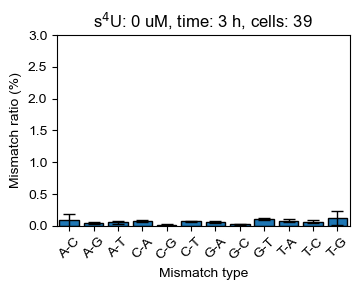

0.69012658122957
0.29094174716578625


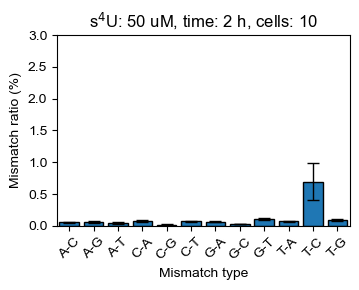

1.081330248817295
0.38311619821745685


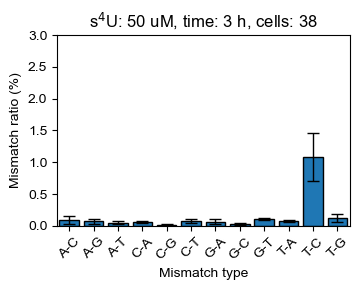

0.35538082561628304
0.18338769224218765


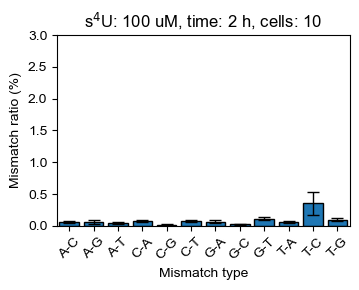

0.7194388639911532
0.24834319130646385


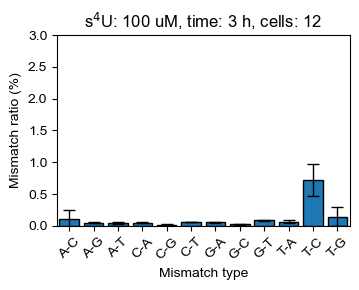

0.224668493648035
0.1460846236236853


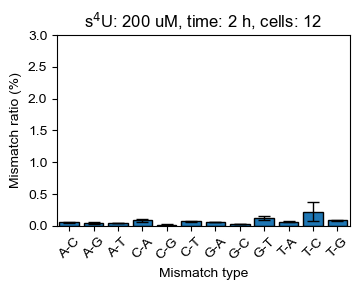

0.4351605655404167
0.1575378782914899


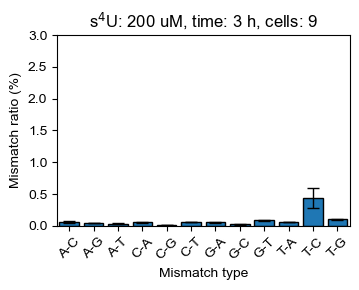

0.23243754482626997
0.1945378127080469


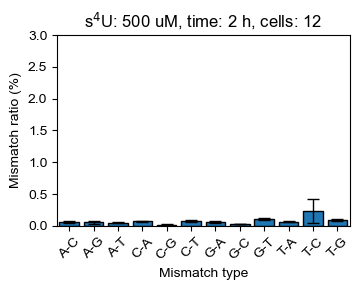

0.09713981642069754
0.009681569094266523


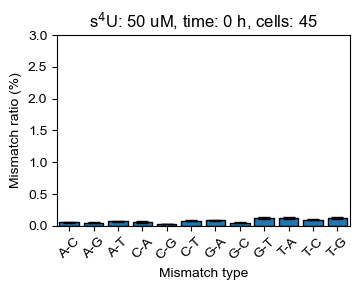

0.3463715553777154
0.1776588858209979


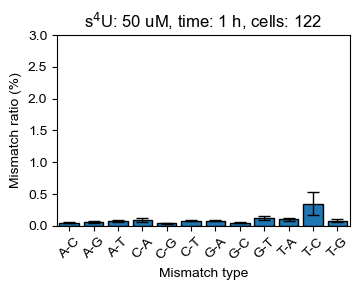

0.10292066956628357
0.009190236687829093


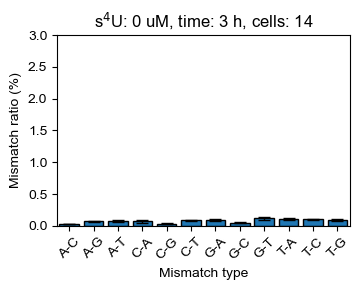

1.3506199879556036
0.571157557261204


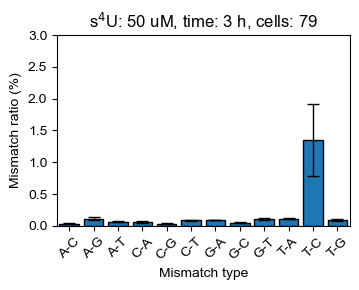

In [4]:
for name, d in data.items():
    for s4u, d1 in d.groupby(by="s4U"):
        for time, d2 in d1.groupby(by="Time"):
            m = d2[["%s.Ratio" % mt for mt in mtypes]] * 100
            print(m.mean()["TC.Ratio"])
            print(m.std()["TC.Ratio"])
            xs = np.arange(len(mtypes))            
            plt.figure(figsize=(3.7, 3))
            plt.title("s$^4$U: %d uM, time: %d h, cells: %d" % (s4u, time, len(d2)))
            plt.bar(xs, m.mean(), yerr=m.std(), edgecolor="black", error_kw=dict(capsize=4, lw=1))
            plt.xticks(xs, ["%s-%s" % (s[0], s[1]) for s in mtypes], rotation=45)
            plt.xlim(-0.5, xs[-1] + 0.5)
            plt.ylim(0, 3)
            plt.xlabel("Mismatch type")
            plt.ylabel("Mismatch ratio (%)")
            plt.tight_layout()
            plt.savefig("figures/mismatch.ratio.%s_s4U%duM%.2fh.pdf" % (name, s4u, time))
            plt.show()
            plt.close()

# Comparison of mismatch ratio and newly reads

Outputs:

    figures/comparison_mismatch_ratio.pdf
    figures/comparison_new_proportion.pdf

In [5]:
info = pd.read_csv("results/NASCseq_Summary.csv", index_col=0)
info = info[info["Stranded.Reads"] >= 200000]
array = []
d = info[(info["Run"] == "GSE128273_NASCseq_SE") & (info["s4U"] == 0) & (info["Time"] == 3)]
array.append(["GSE128273_0uM_3h", d])
d = info[(info["Run"] == "GSE128273_NASCseq") & (info["s4U"] == 50) & (info["Time"] == 0.25)]
array.append(["GSE128273_50uM_0.25h", d])
d = info[(info["Run"] == "GSE128273_NASCseq") & (info["s4U"] == 50) & (info["Time"] == 1)]
array.append(["GSE128273_50uM_1h", d])
d = info[(info["Run"] == "GSE128273_NASCseq_SE") & (info["s4U"] == 50) & (info["Time"] == 3)]
array.append(["GSE128273_50uM_3h", d])
tmp = info[info["Run"].isin(['20220113_NASCseq', '20220321_NASCseq', '20220418_NASCseq'])]
for s4u, d1 in sorted(tmp.groupby(by="s4U")):
    for time, d2 in sorted(d1.groupby(by="Time")):
        array.append(["NASCseq_%duM_%dh" % (s4u, time), d2])

Mismatch ratio of T-C
14	0.001	0.0001	GSE128273_0uM_3h
45	0.001	0.0001	GSE128273_50uM_0.25h
122	0.003	0.0018	GSE128273_50uM_1h
79	0.0141	0.0057	GSE128273_50uM_3h
39	0.0006	0.0002	NASCseq_0uM_3h
10	0.0068	0.0028	NASCseq_50uM_2h
38	0.0101	0.0038	NASCseq_50uM_3h
10	0.003	0.0017	NASCseq_100uM_2h
12	0.0073	0.0024	NASCseq_100uM_3h
12	0.0019	0.0014	NASCseq_200uM_2h
9	0.0042	0.0015	NASCseq_200uM_3h
12	0.0016	0.0019	NASCseq_500uM_2h


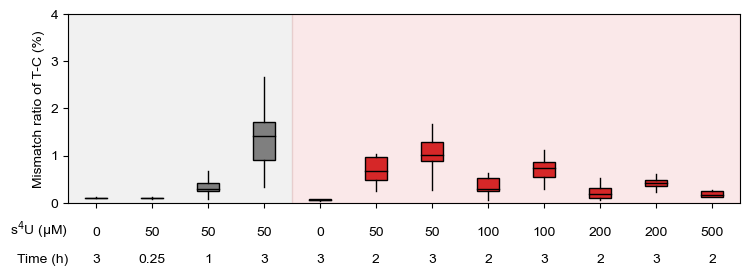

In [6]:
print("Mismatch ratio of T-C")

ylim = 4
w = 0.4
plt.figure(figsize=(7.6, 3))
for i, (name, d) in enumerate(array):
    print(len(d), round(np.median(d["TC.Ratio"]), 4), round(np.std(d["TC.Ratio"]), 4), name, sep="\t")
    color = "C7" if "GSE128273" in name else "C3"
    plt.boxplot([d["TC.Ratio"] * 100], positions=[i], widths=w, 
                patch_artist=True, boxprops=dict(facecolor=color), 
                medianprops=dict(color="black"), 
                showmeans=False,
                flierprops=dict(marker="o", markerfacecolor=color, markeredgecolor="black"), 
                showcaps=False, showfliers=False)
plt.axvspan(-0.5, 3.5, color="C7", alpha=0.1)
plt.axvspan(3.5, 11.5, color="C3", alpha=0.1)
ticks = []
for i, item in enumerate(array):
    items = item[0].split("_")
    ticks.append("\n%s\n\n%s" % (items[1][:-2], items[2][:-1]))
plt.xticks(np.arange(len(array)), ticks, rotation=0)
plt.text(-0.5, -ylim * 0.17, "s$^4$U (μM)", ha="right")
plt.text(-0.5, -ylim * 0.32, "Time (h)", ha="right")
plt.ylabel("Mismatch ratio of T-C (%)")
plt.xlim(-0.5, len(array) - 0.5)
plt.ylim(0, ylim)
plt.tight_layout()
plt.savefig("figures/comparison_mismatch_ratio.pdf")

Percentage of labeled reads
14	0.0159	0.0016	GSE128273_0uM_3h
45	0.0575	0.0066	GSE128273_50uM_0.25h
122	0.0959	0.0375	GSE128273_50uM_1h
79	0.1246	0.0492	GSE128273_50uM_3h
39	0.025	0.0064	NASCseq_0uM_3h
10	0.1105	0.0385	NASCseq_50uM_2h
38	0.1608	0.0612	NASCseq_50uM_3h
10	0.0526	0.027	NASCseq_100uM_2h
12	0.1036	0.0312	NASCseq_100uM_3h
12	0.0383	0.0184	NASCseq_200uM_2h
9	0.07	0.0181	NASCseq_200uM_3h
12	0.0368	0.0241	NASCseq_500uM_2h


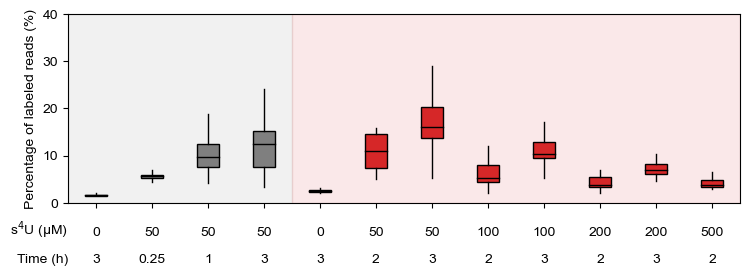

In [7]:
print("Percentage of labeled reads")

ylim = 40
w = 0.4
plt.figure(figsize=(7.6, 3))
for i, (name, d) in enumerate(array):
    print(len(d), round(np.median(d["New.Reads.Ratio"]), 4), round(np.std(d["New.Reads.Ratio"]), 4), name, sep="\t")
    color = "C7" if "GSE128273" in name else "C3"
    plt.boxplot([d["New.Reads.Ratio"] * 100], positions=[i], widths=w, 
                patch_artist=True, boxprops=dict(facecolor=color), 
                medianprops=dict(color="black"), 
                flierprops=dict(marker="o", markerfacecolor=color, markeredgecolor="black"), 
                showcaps=False, showfliers=False)
plt.axvspan(-0.5, 3.5, color="C7", alpha=0.1)
plt.axvspan(3.5, 11.5, color="C3", alpha=0.1)
ticks = []
for i, item in enumerate(array):
    items = item[0].split("_")
    ticks.append("\n%s\n\n%s" % (items[1][:-2], items[2][:-1]))
plt.xticks(np.arange(len(array)), ticks, rotation=0)
plt.text(-0.5, -ylim * 0.17, "s$^4$U (μM)", ha="right")
plt.text(-0.5, -ylim * 0.32, "Time (h)", ha="right")
plt.ylabel("Percentage of labeled reads (%)")
plt.xlim(-0.5, len(array) - 0.5)
plt.ylim(0, ylim)
plt.tight_layout()
plt.savefig("figures/comparison_new_proportion.pdf")